In [17]:
#imports

!pip install numpy pandas matplotlib scikit-learn ucimlrepo seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from ucimlrepo import fetch_ucirepo
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
#loading the dataset
student_performance = fetch_ucirepo(id=320)
X = student_performance.data.features
y = student_performance.data.targets


In [3]:
#inspecting the dataset
print(f"Features number of rows :{X.shape[0]}") #number of rows in the features dataset
print(f"Targets number of rows :{y.shape[0]}") #number of rows in the targets dataset
print(f"Features number of columns :{X.shape[1]}") #number of columns in the features dataset
print(f"Targets number of columns :{y.shape[1]}") #number of columns in the targets dataset

Features number of rows :649
Targets number of rows :649
Features number of columns :30
Targets number of columns :3


- Number of rows match up, shows indexing is done well

In [4]:
#inspecting variable types
X.info()
y.info()
#most of the features are categorical and the target is numerical, whilst some of the features are numerical

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [5]:
#identifying the target variable
#G3 is the final grade, it also is highly correlated with the other two grades G1 and G2, so we will be using it as our target variable
#i will store it under the name y_G3
y_G3 = y["G3"]
#the features remain the same, so i will keep them under the name X


In [6]:
# feature engineering and data cleaning
#checking for null values in the features dataset and the target variable
print(X.isnull().sum())
print(y_G3.isnull().sum())
#there are no null values in the features dataset, so we can proceed to the next step

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64
0


In [7]:
#we will split the dataset into
#Categorical and nominal
# Then we will split the categorical features into ordinal and nominal, ordinal we will encode using label encoding and nominal we will encode using one hot encoding
categorical_features_nominal = X.select_dtypes(include=["str"]).columns
categorical_features_ordinal = X.select_dtypes(include=["int64", "float64"]).columns
print(f"Categorical features nominal: {categorical_features_nominal}")
print(f"Categorical features ordinal: {categorical_features_ordinal}")
#this matches up with what variables we need to split into categorical and numerical from the brief
# essentially categorical features have nominal data, so there is no order of significance. Ordinal data there is an order of significance ex: more absences are worse



Categorical features nominal: Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')
Categorical features ordinal: Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences'],
      dtype='str')


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_G3, test_size=0.2, random_state=42)

In [9]:
#creating a copy of the features dataset just incase
X_copy = X.copy()


In [10]:

#one hot encoding the categorical features
one_hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 
one_hot_encoded_train = one_hot.fit_transform(X_train[categorical_features_nominal]) #only transforming the training set, we will use the same encoder to transform the test set later on
X_train_nominal = pd.DataFrame(one_hot_encoded_train, columns=one_hot.get_feature_names_out(categorical_features_nominal), index=X_train.index) #creating a new dataframe for the one hot encoded features, and keeping the same index as the original dataframe

one_hot_encoded_test = one_hot.transform(X_test[categorical_features_nominal])
X_test_nominal = pd.DataFrame(one_hot_encoded_test, columns=one_hot.get_feature_names_out(categorical_features_nominal), index=X_test.index) #creating a new dataframe for the one hot encoded features, and keeping the same index as the original dataframe
    
#add the new df in places of the old ones for both training and test sets
X_train_encoded = pd.concat(
    [X_train.drop(columns=categorical_features_nominal), X_train_nominal],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test.drop(columns=categorical_features_nominal), X_test_nominal],
    axis=1
)

In [11]:
#scaling numerical inputs for knn
StandardScaler = preprocessing.StandardScaler()

X_train_knn_scaled = StandardScaler.fit_transform(X_train_encoded)
X_test_knn_scaled = StandardScaler.transform(X_test_encoded)

X_train_knn_scaled = pd.concat(
    [pd.DataFrame(X_train_knn_scaled, columns=X_train_encoded.columns, index=X_train.index)],
    axis=1
)

X_test_knn_scaled = pd.concat(
    [pd.DataFrame(X_test_knn_scaled, columns=X_test_encoded.columns, index=X_test.index)],
    axis=1
)

****EDA****
1. We will conduct summary statistics for the feature engineered dataset
2. A histogram of the final grade
3. Find some meaningfull relationships between some variables

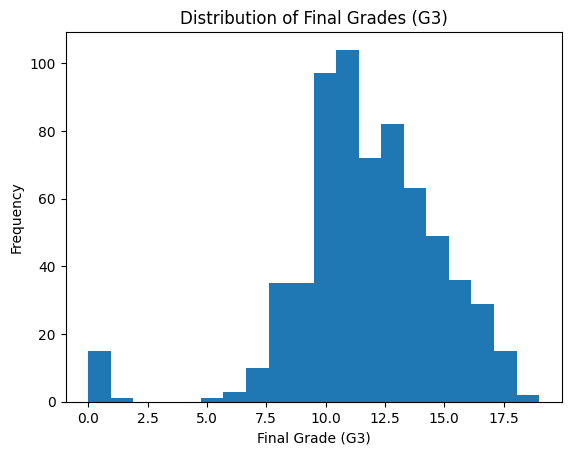

In [12]:
# histogram of final grade
plt.hist(y_G3, bins=20)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.show()


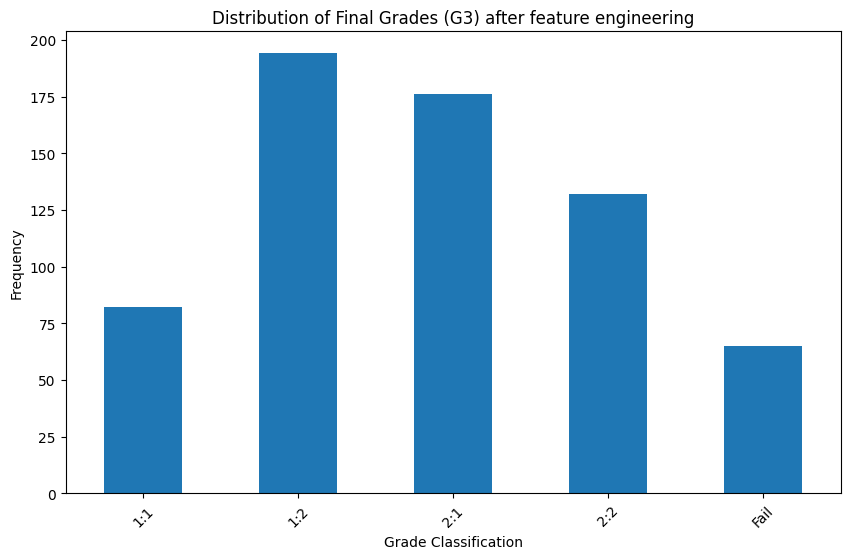

In [13]:
# we will feature engineer the final grades to see where students lie the most
# Create a new Series for classification
y_G3_classified = pd.Series(index=y_G3.index, dtype='object')

y_G3_classified.loc[y_G3 >= 16] = '1:1'
y_G3_classified.loc[y_G3.between(13, 15)] = '1:2'
y_G3_classified.loc[y_G3.between(11, 12)] = '2:1'
y_G3_classified.loc[y_G3.between(9, 10)] = '2:2'
y_G3_classified.loc[y_G3 < 9] = 'Fail'

# plotting the distribution of the final grades after feature engineering
plt.figure(figsize=(10, 6))
y_G3_classified.value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Final Grades (G3) after feature engineering")
plt.xlabel("Grade Classification")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


In [14]:
X

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,yes,yes,no,5,4,2,1,2,5,4
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,yes,no,4,3,4,1,1,1,4
646,MS,F,18,U,GT3,T,1,1,other,other,...,yes,no,no,1,1,1,1,1,5,6
647,MS,M,17,U,LE3,T,3,1,services,services,...,yes,yes,no,2,4,5,3,4,2,6


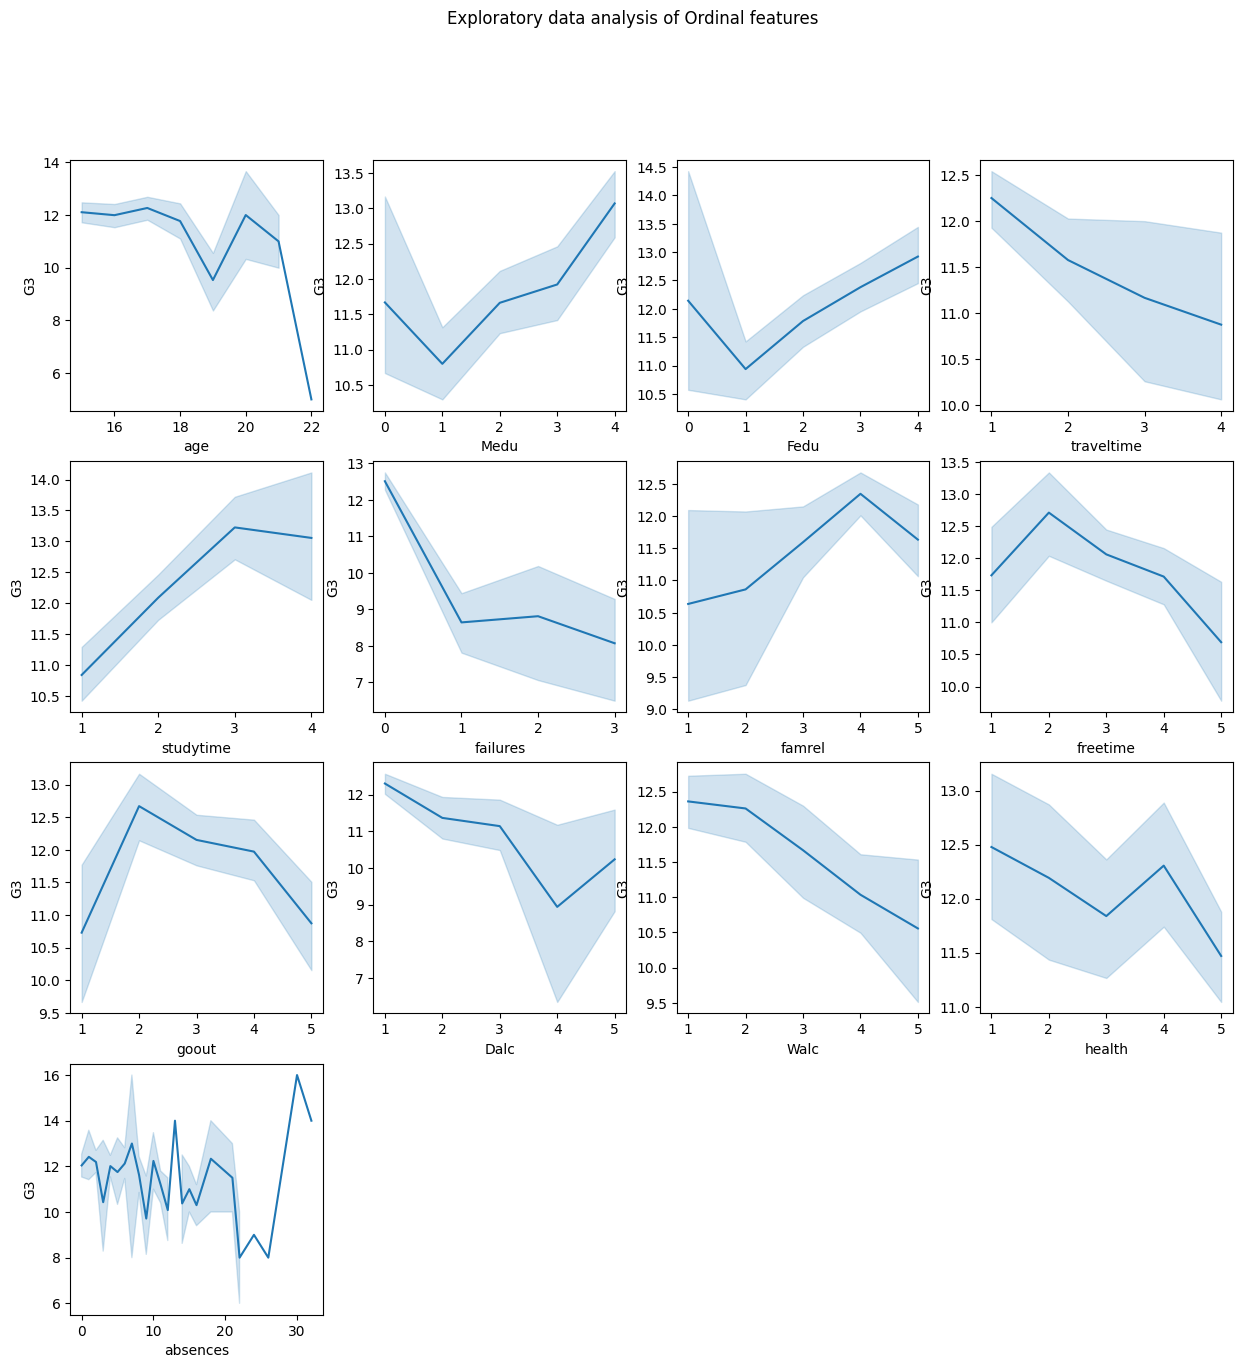

In [ ]:

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle("Exploratory data analysis of Ordinal features")
for i, feature in enumerate(categorical_features_ordinal):
    sns.lineplot(ax = axes[i//4, i%4], x=X[feature], y = y_G3)
plots_to_delete = [(3, 3), (3, 2), (3, 1)] #empty plots to delete since we have 13 features and not 16
for row, col in plots_to_delete:
    fig.delaxes(axes[row, col]) # removing the last subplot since we have 13 features and not 16


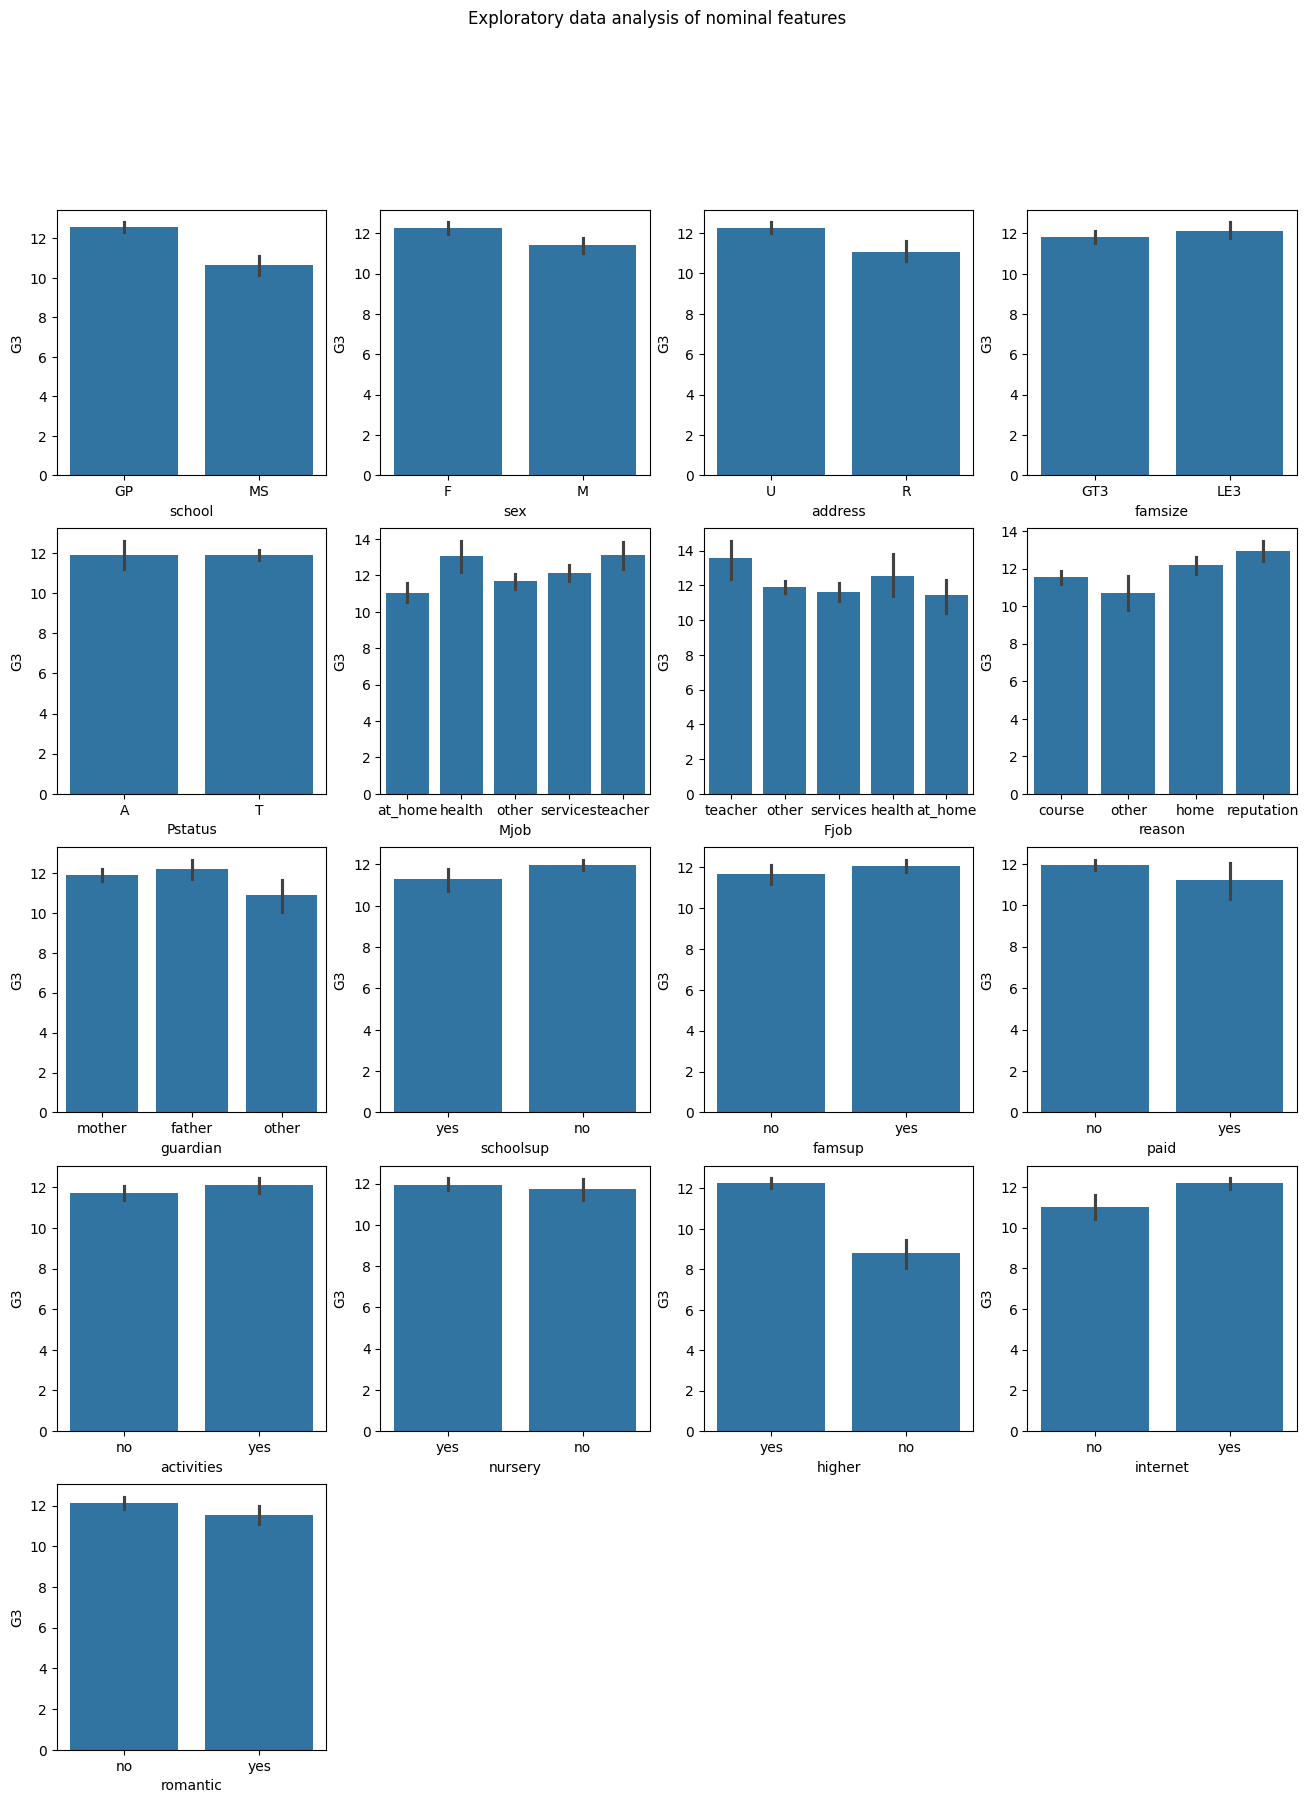

In [64]:

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
fig.suptitle("Exploratory data analysis of nominal features")
for i, feature in enumerate(categorical_features_nominal):
    sns.barplot(ax = axes[i//4, i%4], x=X[feature], y = y_G3)
plots_to_delete = [(4, 3), (4, 2), (4, 1)] #empty plots to delete since we have 13 features and not 16
for row, col in plots_to_delete:
    fig.delaxes(axes[row, col]) # removing the last subplot since we have 13 features and not 16


In [35]:
len(categorical_features_nominal)

17

In [36]:
len(categorical_features_ordinal)

13

In [65]:
categorical_features_nominal

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')